In [195]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [197]:

ds = pd.read_csv(r"C:\Users\pc\Downloads\task1\dataset\restaurant_sales_data.csv")
ds.columns = ['Order ID', 'Customer ID', 'Category', 'Item', 'Price', 'Quantity', 'Order Total', 'Order Date', 'Payment Method']

In [241]:
ds

,order id,customer id,category,item,price,quantity,order total,order date,payment method,month-year
0,ORD_705844,CUST_092,Side Dishes,Side Salad,3.0,1.0,3.0,2023-12-21,Credit Card,2023-12
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet,2023-05
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card,2023-09
3,ORD_630508,CUST_075,Drinks,Lemonade,3.0,2.0,5.0,2022-08-09,Credit Card,2022-08
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash,2022-05
...,...,...,...,...,...,...,...,...,...,...
17529,ORD_320102,CUST_021,Drinks,Lemonade,3.0,4.0,4.0,2023-12-23,Cash,2023-12
17530,ORD_974128,CUST_069,Desserts,Ice Cream,5.0,3.0,15.0,2023-12-18,Cash,2023-12
17531,ORD_108324,CUST_050,Desserts,Ice Cream,5.0,4.0,20.0,2022-05-20,Digital Wallet,2022-05
17532,ORD_612647,CUST_073,Side Dishes,Mashed Potatoes,4.0,2.0,8.0,2022-01-27,Digital Wallet,2022-01


In [199]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            15776 non-null  object 
 4   Price           16658 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  16452 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB


In [201]:
missing_values = ds.isna().sum()
missing_values

Order ID             0
Customer ID          0
Category             0
Item              1758
Price              876
Quantity           430
Order Total        430
Order Date           0
Payment Method    1082
dtype: int64

In [203]:
menu = ds[['Category', 'Item', 'Price']].drop_duplicates().dropna().reset_index(drop=True)  # بعمل دروب للانديكس الاساسي
print(menu.to_string()) # index true bu default

       Category                Item  Price
0   Side Dishes          Side Salad    3.0
1   Side Dishes     Mashed Potatoes    4.0
2   Main Dishes     Grilled Chicken   15.0
3   Main Dishes       Pasta Alfredo   12.0
4   Main Dishes              Salmon   18.0
5   Side Dishes        Garlic Bread    4.0
6   Main Dishes  Vegetarian Platter   14.0
7      Desserts             Brownie    6.0
8      Starters  Sweet Potato Fries    5.0
9        Drinks            Lemonade    3.0
10       Drinks        Orange Juice    3.0
11     Desserts      Chocolate Cake    6.0
12       Drinks           Coca Cola    2.5
13  Side Dishes  Grilled Vegetables    5.0
14     Starters        Cheese Fries    5.0
15     Starters          Beef Chili    7.0
16     Starters        Chicken Melt    8.0
17     Desserts         Fruit Salad    4.0
18     Starters        French Fries    4.0
19     Desserts           Ice Cream    5.0
20     Desserts          Cheesecake    7.0
21       Drinks            Iced Tea    2.5
22       Dr

In [205]:
missingvalues = menu[['Item', 'Price']].isna().sum()
missingvalues

Item     0
Price    0
dtype: int64

In [207]:
ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            15776 non-null  object 
 4   Price           16658 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  16452 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB


In [209]:

ds['Price'] = ds['Price'].fillna(ds['Item'].map(menu.set_index('Item')['Price']))
ds['Item'] = ds['Item'].fillna(ds['Category'].map(menu.groupby('Category')['Item'].first()))
ds['Price'] = ds['Price'].fillna(ds['Item'].map(menu.set_index('Item')['Price']))

In [211]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            17534 non-null  object 
 4   Price           17534 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  16452 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB


In [213]:
ds['Payment Method'] = ds['Payment Method'].fillna(ds['Payment Method'].mode()[0])

In [215]:
ds.info()
rows_with_missing = ds[ds.isnull().any(axis=1)]
print(rows_with_missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            17534 non-null  object 
 4   Price           17534 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  17534 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB
         Order ID Customer ID     Category             Item  Price  Quantity  \
75     ORD_367023    CUST_055  Side Dishes       Side Salad    3.0       NaN   
118    ORD_627458    CUST_058  Side Dishes       Side Salad    3.0       NaN   
131    ORD_467157    CUST_099       Drinks         Lemonade    3.0       NaN   
240    ORD_467033    CUST

In [217]:
ds.info()
missing_percentage = ds['Quantity'].isna().mean() * 100
print(f"Missing data in Quantity: {missing_percentage:.2f}%")
ds['Quantity'] = ds['Quantity'].fillna(ds['Order Total'] / ds['Price'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            17534 non-null  object 
 4   Price           17534 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  17534 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB
Missing data in Quantity: 2.45%


مش هتعملي مشكلة بالعكس مش هتخليني افقد كل الداتا بتاعة بقيت الصفوف  median كدة  عندي القيم المفقودة حوالي 2 ونص في المية ودي نسبة قليلة جدا لو جبتها ب  

In [220]:
ds['Quantity'] = ds['Quantity'].fillna(ds['Quantity'].median())
ds['Order Total'] = ds['Order Total'].fillna(ds['Price'] * ds['Quantity'])

In [222]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            17534 non-null  object 
 4   Price           17534 non-null  float64
 5   Quantity        17534 non-null  float64
 6   Order Total     17534 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  17534 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB


C:\Users\pc\AppData\Local\Temp\ipykernel_1796\4226443826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_products.index, x=top_products.values, palette='rocket')


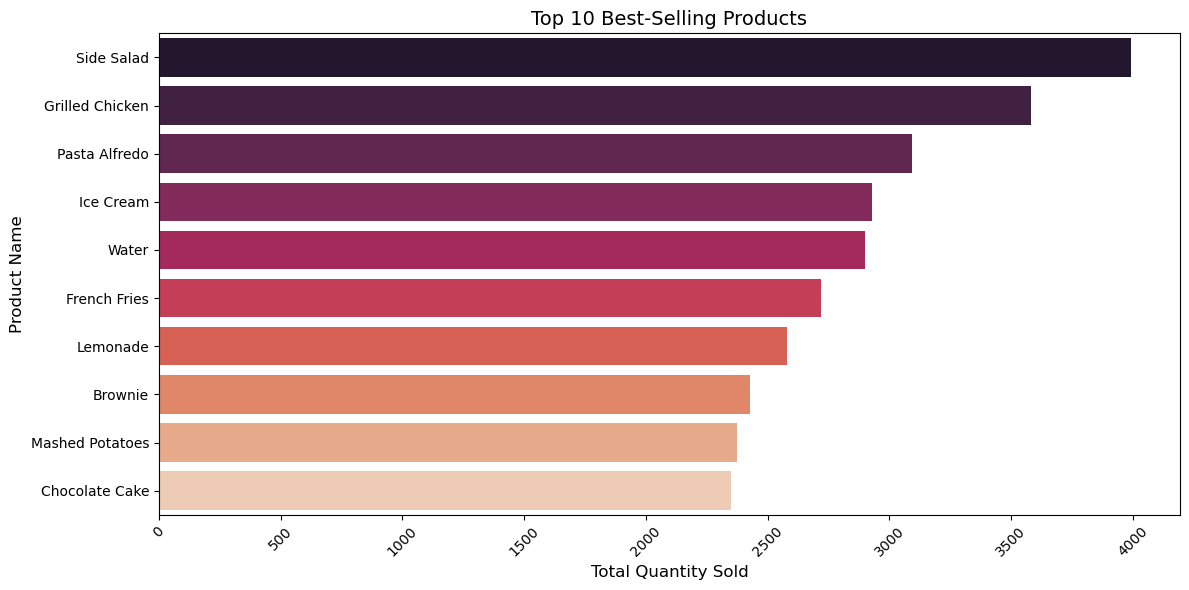

In [224]:

plt.figure(figsize=(12,6))
top_products = ds.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_products.index, x=top_products.values, palette='rocket')
plt.title('Top 10 Best-Selling Products', fontsize=14)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_1796\3519532852.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')


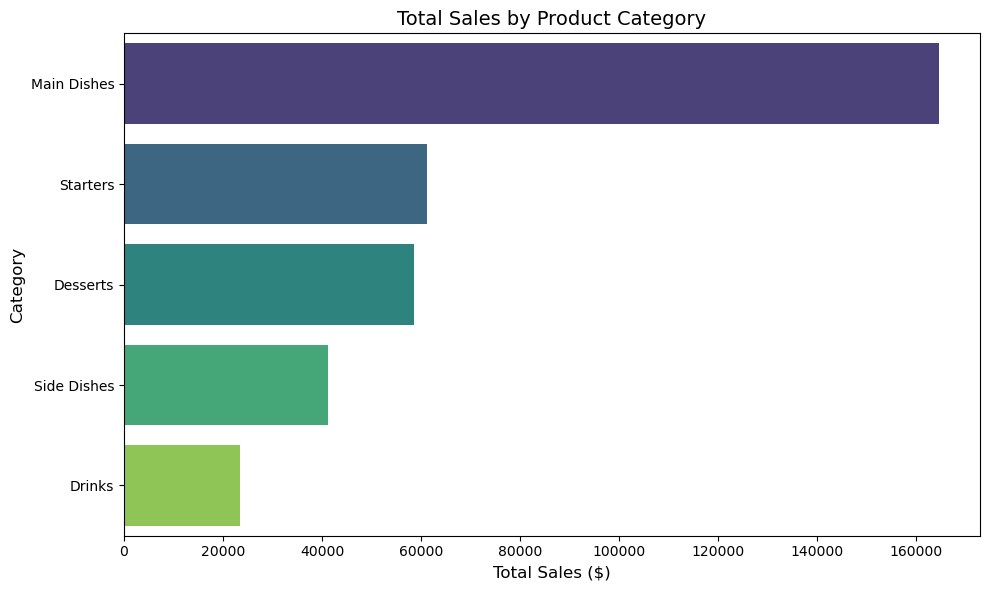

In [226]:
plt.figure(figsize=(10,6))
category_sales = ds.groupby('Category')['Order Total'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Total Sales by Product Category', fontsize=14)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

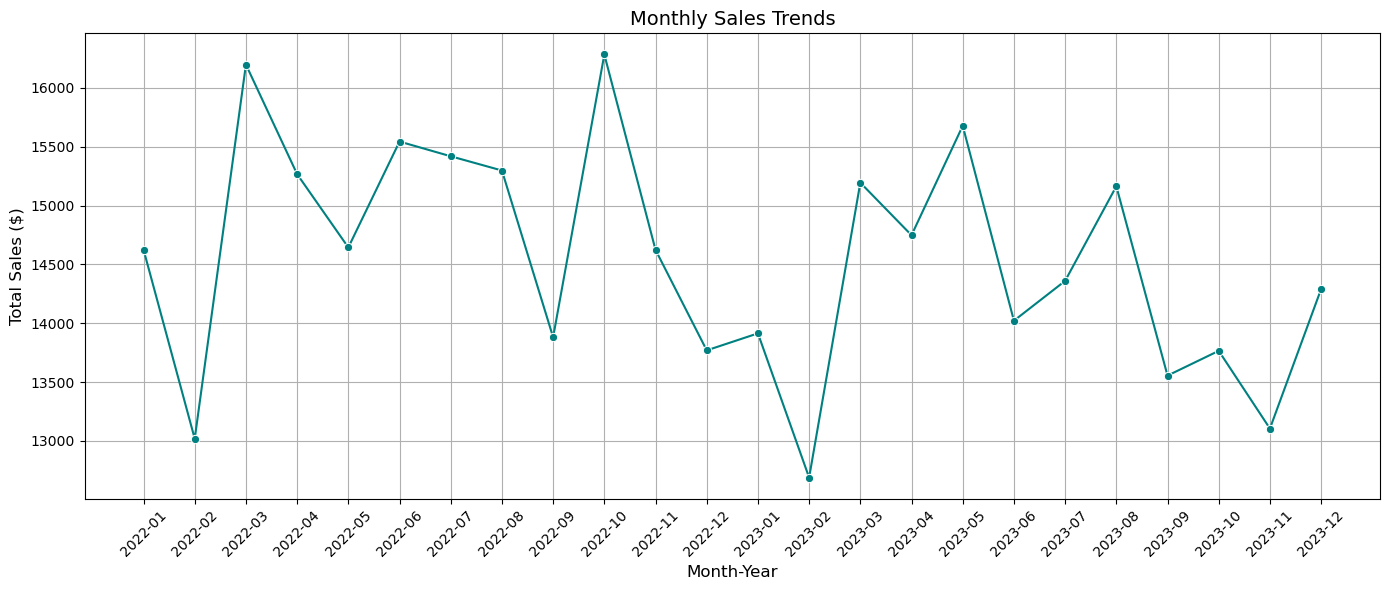

In [228]:
ds['Order Date'] = pd.to_datetime(ds['Order Date'])
ds['Month-Year'] = ds['Order Date'].dt.to_period('M').astype(str)
monthly_sales = ds.groupby('Month-Year')['Order Total'].sum()

plt.figure(figsize=(14,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='teal')
plt.title('Monthly Sales Trends', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_1796\1224434917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.values, y=payment_counts.index, palette='mako')


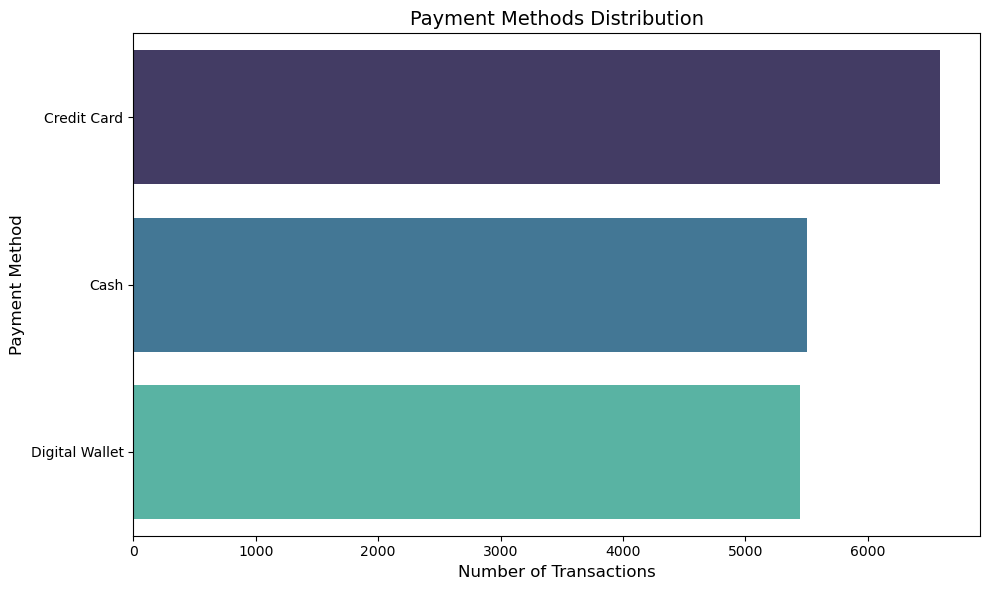

In [230]:
plt.figure(figsize=(10,6))
payment_counts = ds['Payment Method'].value_counts()
sns.barplot(x=payment_counts.values, y=payment_counts.index, palette='mako')
plt.title('Payment Methods Distribution', fontsize=14)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Payment Method', fontsize=12)
plt.tight_layout()
plt.show()

 What is the maximum price?

In [233]:
ds.columns = ds.columns.str.strip().str.lower()
ds['price'] = ds['price'].replace(r'[^\d.]', '', regex=True).astype(float)
max_price = ds['price'].max()
print(f"The maximum price is: ${max_price}")

The maximum price is: $20.0


What is the minimum price?

In [236]:
min_price = ds['price'].min()
print(f"The minimum price is: ${min_price}")

The minimum price is: $1.0


Which product has the highest price?

In [239]:
count_high_price = ds[ds['price'] > 500].shape[0]
print(f"Number of products with price > $500: {count_high_price}")

Number of products with price > $500: 0


C:\Users\pc\AppData\Local\Temp\ipykernel_1796\3552501840.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_order_payment.index, y=avg_order_payment.values, palette='Set1')


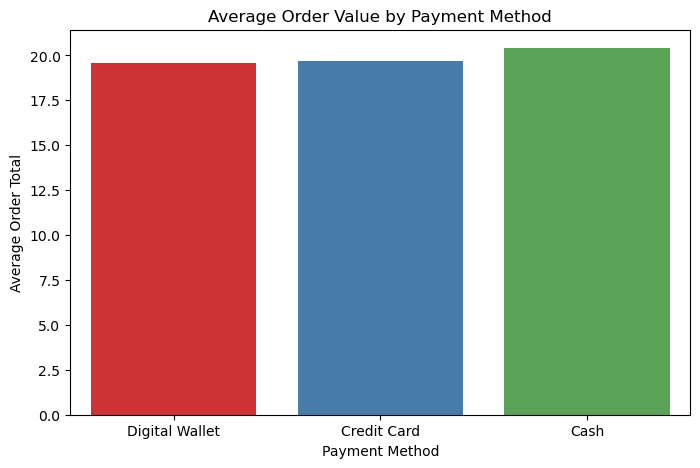

In [245]:

ds = pd.read_csv(r"C:\Users\pc\Downloads\task1\dataset\restaurant_sales_data.csv")

ds.columns = ['Order ID', 'Customer ID', 'Category', 'Item', 'Price', 'Quantity', 'Order Total', 'Order Date', 'Payment Method']
# Q8: What is the Average Order Value (AOV) for each payment method?
plt.figure(figsize=(8, 5))
avg_order_payment = ds.groupby('Payment Method')['Order Total'].mean().sort_values()
sns.barplot(x=avg_order_payment.index, y=avg_order_payment.values, palette='Set1')

plt.title('Average Order Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Order Total')
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_1796\2344441106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue_items.values, y=top_revenue_items.index, palette='viridis')


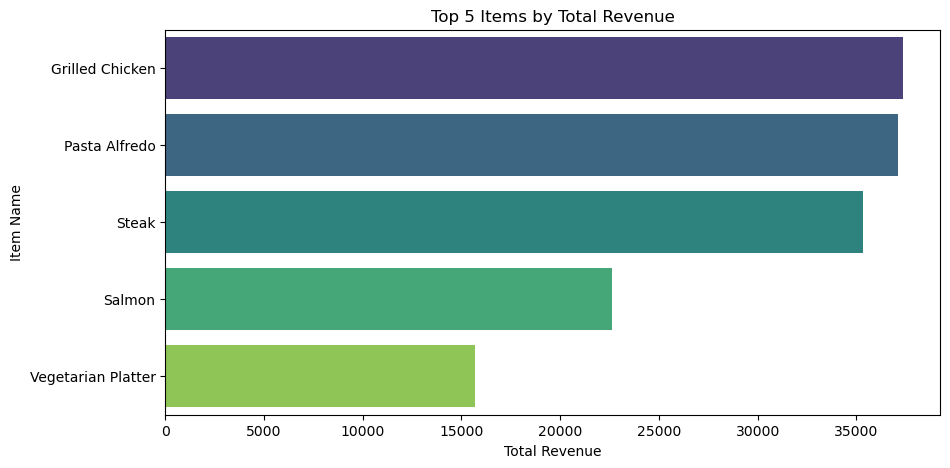

In [247]:
# Q9: Which top 5 items generate the highest total revenue?
plt.figure(figsize=(10, 5))
top_revenue_items = ds.groupby('Item')['Order Total'].sum().nlargest(5)
sns.barplot(x=top_revenue_items.values, y=top_revenue_items.index, palette='viridis')

plt.title('Top 5 Items by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Item Name')
plt.show()

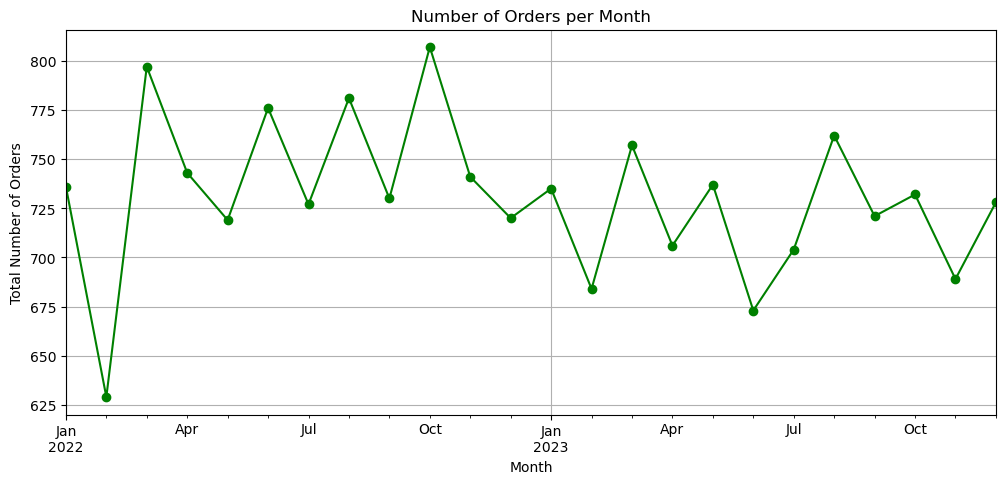

In [249]:
# Q10: How does the number of orders vary by month?
ds['Order Date'] = pd.to_datetime(ds['Order Date'])
ds['Month_Year'] = ds['Order Date'].dt.to_period('M')

monthly_orders = ds.groupby('Month_Year')['Order ID'].count()

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='green')
plt.title('Number of Orders per Month')
plt.xlabel('Month')
plt.ylabel('Total Number of Orders')
plt.grid(True)
plt.show()

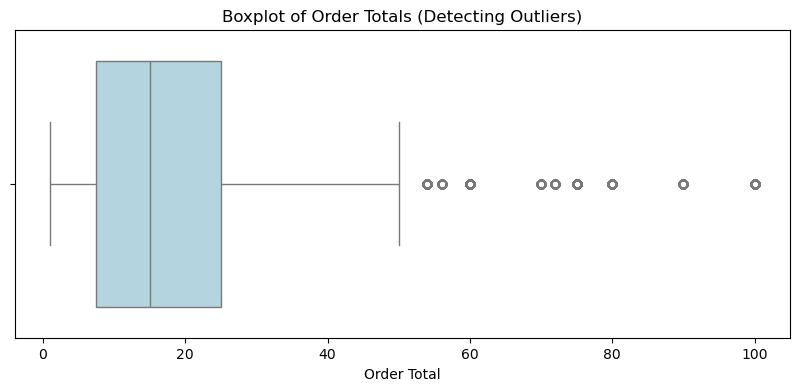

In [251]:
# Q11: Are there any outliers in the Order Total values?
plt.figure(figsize=(10, 4))
sns.boxplot(x=ds['Order Total'], color='lightblue')

plt.title('Boxplot of Order Totals (Detecting Outliers)')
plt.xlabel('Order Total')
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_1796\2154600745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ds, x='Quantity', palette='mako')


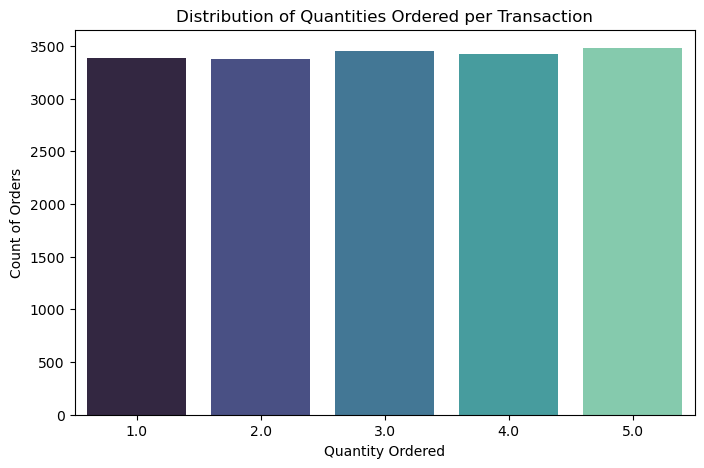

In [253]:
# Q12: What is the distribution of quantities ordered per transaction?
plt.figure(figsize=(8, 5))
sns.countplot(data=ds, x='Quantity', palette='mako')

plt.title('Distribution of Quantities Ordered per Transaction')
plt.xlabel('Quantity Ordered')
plt.ylabel('Count of Orders')
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_1796\256734944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_cat.index, y=avg_price_cat.values, palette='plasma')


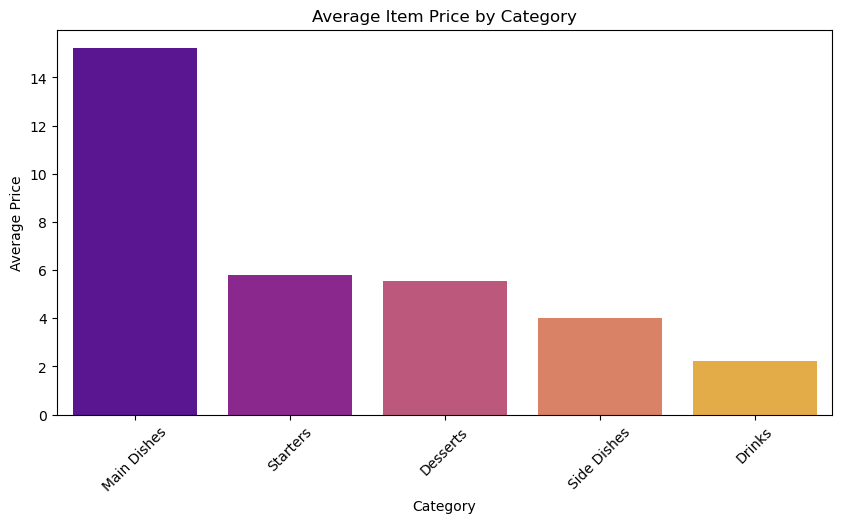

In [255]:
# Q13: Which category has the highest average item price?
plt.figure(figsize=(10, 5))
avg_price_cat = ds.groupby('Category')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_cat.index, y=avg_price_cat.values, palette='plasma')

plt.title('Average Item Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

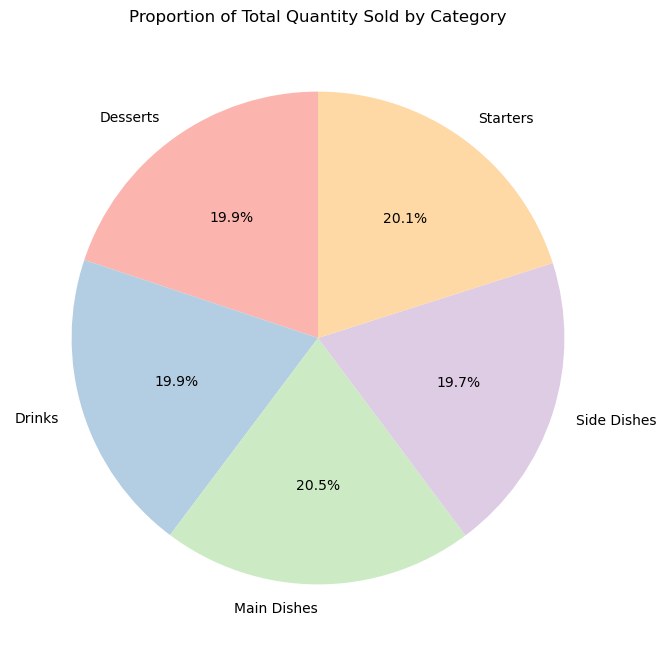

In [259]:
# Q14: What is the proportion of total items sold (Quantity) by each category?
plt.figure(figsize=(8, 8))
category_quantity = ds.groupby('Category')['Quantity'].sum()
plt.pie(category_quantity, labels=category_quantity.index, autopct='%1.1f%%', colors=sns.color_palette('Pastel1'), startangle=90)
plt.title('Proportion of Total Quantity Sold by Category')
plt.show()

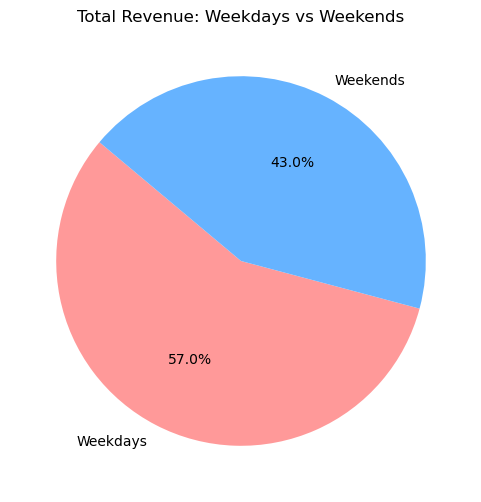

In [261]:
# Q15: How do sales compare between Weekdays and Weekends?
ds['Day Name'] = ds['Order Date'].dt.day_name()

ds['Is Weekend'] = ds['Day Name'].isin(['Friday', 'Saturday', 'Sunday'])

weekend_sales = ds.groupby('Is Weekend')['Order Total'].sum()

plt.figure(figsize=(6, 6))
weekend_sales.plot(kind='pie', labels=['Weekdays', 'Weekends'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title('Total Revenue: Weekdays vs Weekends')
plt.ylabel('')
plt.show()